In [2]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 730.2 kB/s eta 0:02:19
   ---------------------------------------- 0.8/101.7 MB 838.9 kB/s eta 0:02:01
   ---------------------------------------- 1.0/101.7 MB 1.1 MB/s eta 0:01:34
    --------------------------------------- 2.1/101.7 MB 1.8 MB/s eta 0:00:57
   - ---------------------------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

# For handling imbalanced data
from sklearn.utils.class_weight import compute_class_weight

# Save model
import joblib

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ All libraries imported!")

✅ All libraries imported!


In [4]:
# Load the cleaned data
df = pd.read_csv('../outputs/cleaned_data.csv')

print("="*50)
print("DATA LOADED SUCCESSFULLY")
print("="*50)
print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.shape[1]}")
print(f"🎯 Target: Churn (1=churned, 0=stayed)")

print("\n📋 First few rows:")
df.head()

DATA LOADED SUCCESSFULLY
📊 Dataset shape: (7043, 7077)
📋 Columns: 7077
🎯 Target: Churn (1=churned, 0=stayed)

📋 First few rows:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,avg_monthly_charge,service_count,has_multiple_lines,is_senior
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,True,False,True,False,14.925000,1,False,0
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,True,False,False,False,False,True,53.985714,2,False,0
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,True,False,False,True,36.050000,2,False,0
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,True,False,False,False,False,False,40.016304,3,False,0
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,True,False,True,False,50.550000,0,False,0


In [5]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print("="*50)
print("FEATURES AND TARGET SEPARATED")
print("="*50)
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeatures list: {X.columns.tolist()[:10]}... (showing first 10)")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"Churn rate: {(y.sum() / len(y)) * 100:.1f}%")

FEATURES AND TARGET SEPARATED
Features (X) shape: (7043, 7076)
Target (y) shape: (7043,)

Features list: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE']... (showing first 10)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%


In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("="*50)
print("TRAIN-TEST SPLIT")
print("="*50)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"\nTraining set churn rate: {(y_train.sum() / len(y_train)) * 100:.1f}%")
print(f"Test set churn rate: {(y_test.sum() / len(y_test)) * 100:.1f}%")

# Check stratification worked
print("\n✅ Stratification successful! Both sets have similar churn rates.")

TRAIN-TEST SPLIT
Training set: 5634 samples (80%)
Test set: 1409 samples (20%)

Training set churn rate: 26.5%
Test set churn rate: 26.5%

✅ Stratification successful! Both sets have similar churn rates.


In [7]:
# Scale numerical features for better model performance
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*50)
print("FEATURE SCALING")
print("="*50)
print("✅ Features scaled using StandardScaler")
print(f"Training data scaled shape: {X_train_scaled.shape}")
print(f"Test data scaled shape: {X_test_scaled.shape}")

# Save the scaler for later use
joblib.dump(scaler, '../outputs/scaler.pkl')
print("✅ Scaler saved to: outputs/scaler.pkl")

FEATURE SCALING
✅ Features scaled using StandardScaler
Training data scaled shape: (5634, 7076)
Test data scaled shape: (1409, 7076)
✅ Scaler saved to: outputs/scaler.pkl


In [8]:
print("="*50)
print("BUILDING MODELS")
print("="*50)

# Calculate class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight=class_weight_dict, 
        random_state=42, 
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        class_weight=class_weight_dict, 
        random_state=42, 
        n_estimators=100
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=class_weights[1]/class_weights[0],
        random_state=42, 
        eval_metric='logloss',
        use_label_encoder=False
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

# Train and evaluate each model
results = {}

print("\n📊 Training and evaluating models...\n")

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"✅ {name}:")
    print(f"   Accuracy: {results[name]['Accuracy']:.4f}")
    print(f"   Precision: {results[name]['Precision']:.4f}")
    print(f"   Recall: {results[name]['Recall']:.4f}")
    print(f"   F1 Score: {results[name]['F1 Score']:.4f}")
    print(f"   ROC-AUC: {results[name]['ROC-AUC']:.4f}")
    print()

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(results_df.round(4))

BUILDING MODELS
Class weights: {0: 0.6805991785455424, 1: 1.8842809364548494}

📊 Training and evaluating models...

✅ Logistic Regression:
   Accuracy: 0.7892
   Precision: 0.6546
   Recall: 0.4358
   F1 Score: 0.5233
   ROC-AUC: 0.8300

✅ Random Forest:
   Accuracy: 0.8034
   Precision: 0.6751
   Recall: 0.5000
   F1 Score: 0.5745
   ROC-AUC: 0.8304

✅ XGBoost:
   Accuracy: 0.7551
   Precision: 0.5313
   Recall: 0.6578
   F1 Score: 0.5878
   ROC-AUC: 0.8193

✅ Gradient Boosting:
   Accuracy: 0.7921
   Precision: 0.6473
   Recall: 0.4759
   F1 Score: 0.5485
   ROC-AUC: 0.8455


MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7892     0.6546  0.4358    0.5233   0.8300
Random Forest          0.8034     0.6751  0.5000    0.5745   0.8304
XGBoost                0.7551     0.5313  0.6578    0.5878   0.8193
Gradient Boosting      0.7921     0.6473  0.4759    0.5485   0.8455


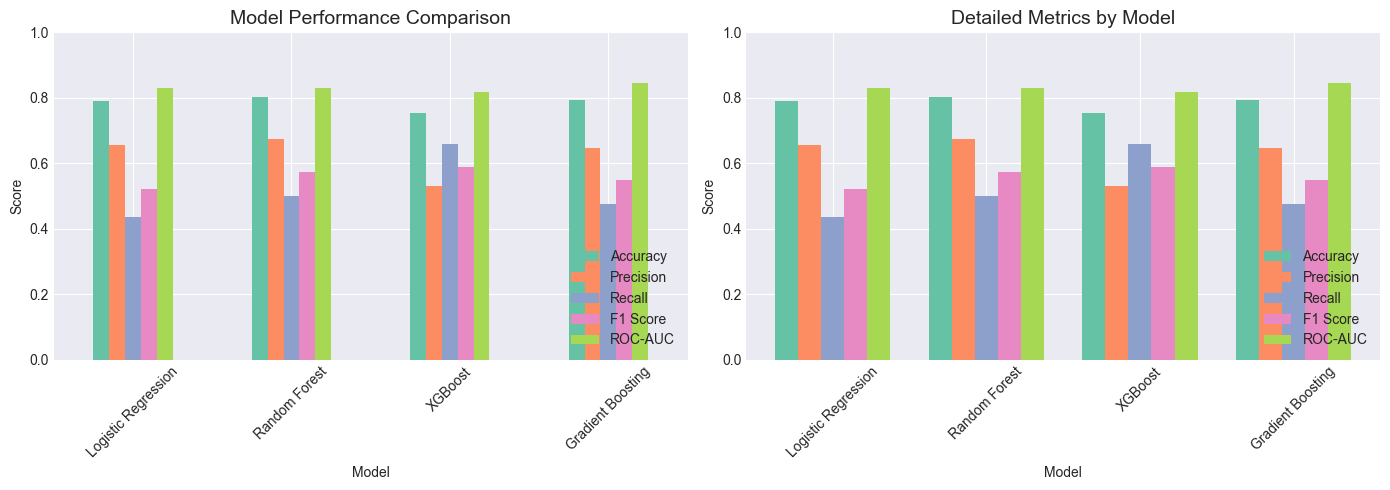

In [9]:
# Plot model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
results_df.plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison', fontsize=14)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0, 1])
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=45)

# ROC-AUC comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(results_df.index))
width = 0.15
multiplier = 0

for metric in metrics:
    offset = width * multiplier
    axes[1].bar(x + offset, results_df[metric], width, label=metric)
    multiplier += 1

axes[1].set_title('Detailed Metrics by Model', fontsize=14)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(results_df.index, rotation=45)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

BEST MODEL: Gradient Boosting


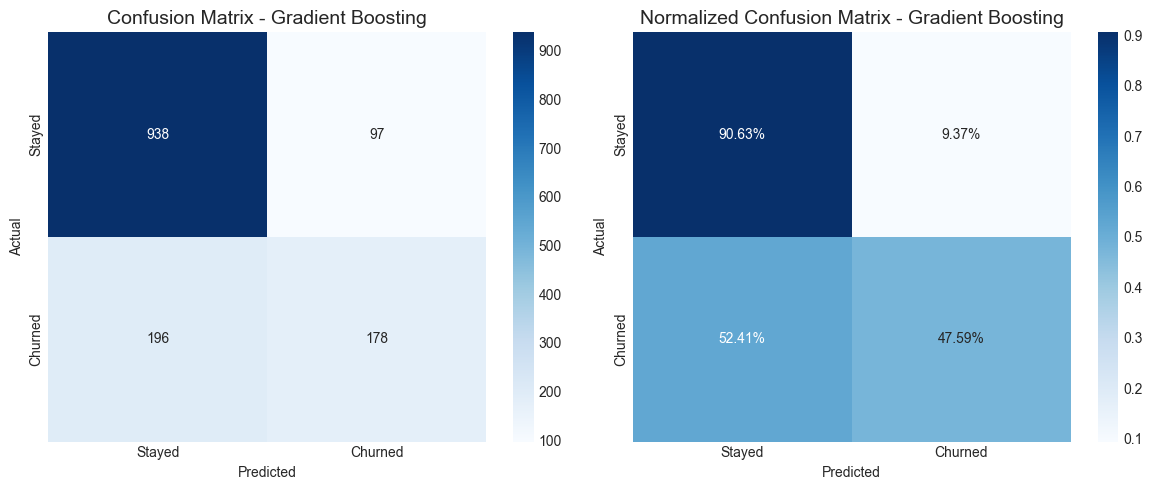


📊 Confusion Matrix Interpretation:
   True Negatives (correctly predicted stayed): 938
   False Positives (predicted churned but stayed): 97
   False Negatives (predicted stayed but churned): 196
   True Positives (correctly predicted churned): 178

   Accuracy: 79.21%
   Precision: 64.73% (Of those predicted to churn, how many actually did)
   Recall: 47.59% (Of actual churners, how many did we catch)


In [10]:
# Find best model (based on ROC-AUC)
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = models[best_model_name]

print("="*50)
print(f"BEST MODEL: {best_model_name}")
print("="*50)

# Get predictions
y_pred_best = best_model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Stayed', 'Churned'])
axes[0].set_yticklabels(['Stayed', 'Churned'])

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Normalized Confusion Matrix - {best_model_name}', fontsize=14)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['Stayed', 'Churned'])
axes[1].set_yticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Confusion Matrix Interpretation:")
print(f"   True Negatives (correctly predicted stayed): {tn}")
print(f"   False Positives (predicted churned but stayed): {fp}")
print(f"   False Negatives (predicted stayed but churned): {fn}")
print(f"   True Positives (correctly predicted churned): {tp}")
print(f"\n   Accuracy: {(tn+tp)/(tn+fp+fn+tp):.2%}")
print(f"   Precision: {tp/(tp+fp):.2%} (Of those predicted to churn, how many actually did)")
print(f"   Recall: {tp/(tp+fn):.2%} (Of actual churners, how many did we catch)")

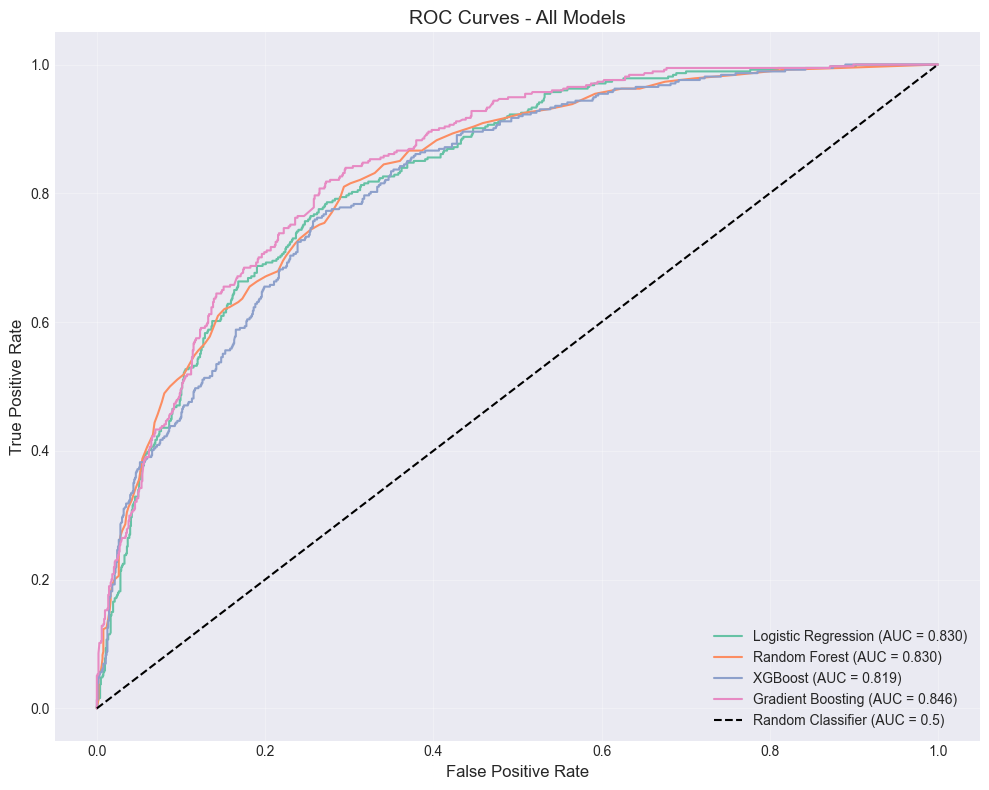

✅ ROC Curves saved to: outputs/roc_curves.png

💡 Interpretation: Higher AUC = Better model at distinguishing churners from non-churners


In [11]:
# ROC Curve for all models
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC Curves saved to: outputs/roc_curves.png")
print("\n💡 Interpretation: Higher AUC = Better model at distinguishing churners from non-churners")

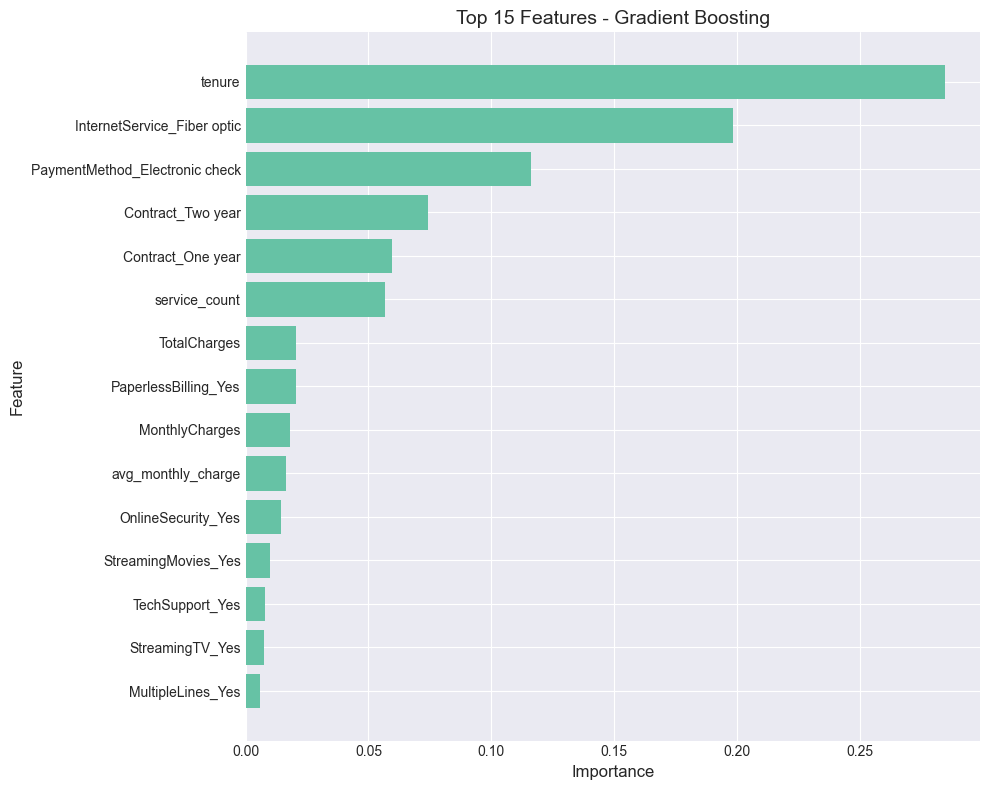


📊 TOP 10 MOST IMPORTANT FEATURES:
   tenure: 0.2847
   InternetService_Fiber optic: 0.1984
   PaymentMethod_Electronic check: 0.1162
   Contract_Two year: 0.0744
   Contract_One year: 0.0597
   service_count: 0.0569
   TotalCharges: 0.0206
   PaperlessBilling_Yes: 0.0206
   MonthlyCharges: 0.0181
   avg_monthly_charge: 0.0165

✅ Feature importance saved to: outputs/feature_importance.csv


In [12]:
# Get feature importance from Random Forest or XGBoost
if best_model_name in ['Random Forest', 'XGBoost', 'Gradient Boosting']:
    
    # Get feature importances
    if best_model_name == 'XGBoost':
        importances = best_model.feature_importances_
    else:
        importances = best_model.feature_importances_
    
    # Create DataFrame
    feature_importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Plot top 15 features
    plt.figure(figsize=(10, 8))
    top_features = feature_importance_df.head(15)
    plt.barh(top_features['feature'], top_features['importance'])
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title(f'Top 15 Features - {best_model_name}', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../outputs/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 TOP 10 MOST IMPORTANT FEATURES:")
    print("="*40)
    for idx, row in feature_importance_df.head(10).iterrows():
        print(f"   {row['feature']}: {row['importance']:.4f}")
    
    # Save feature importance
    feature_importance_df.to_csv('../outputs/feature_importance.csv', index=False)
    print("\n✅ Feature importance saved to: outputs/feature_importance.csv")
else:
    print(f"Feature importance not available for {best_model_name}")
    print("Using Logistic Regression coefficients instead...")
    
    # For Logistic Regression
    coef_df = pd.DataFrame({
        'feature': X.columns,
        'coefficient': best_model.coef_[0]
    }).sort_values('coefficient', ascending=False)
    
    plt.figure(figsize=(10, 8))
    top_coef = coef_df.head(15)
    plt.barh(top_coef['feature'], top_coef['coefficient'])
    plt.xlabel('Coefficient', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title(f'Top 15 Features - {best_model_name}', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../outputs/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

In [13]:
print("="*50)
print(f"CROSS-VALIDATION - {best_model_name}")
print("="*50)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print(f"Cross-validation ROC-AUC scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Test Set Score: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")

# Check if model is stable
if abs(cv_scores.mean() - results_df.loc[best_model_name, 'ROC-AUC']) < 0.05:
    print("\n✅ Model is stable! Training and CV scores are consistent.")
else:
    print("\n⚠️ Model might be overfitting. Consider more regularization.")

CROSS-VALIDATION - Gradient Boosting
Cross-validation ROC-AUC scores: [0.86291059 0.85833212 0.85225106 0.84222368 0.82209946]
Mean CV Score: 0.8476 (+/- 0.0290)
Test Set Score: 0.8455

✅ Model is stable! Training and CV scores are consistent.


In [14]:
print("="*50)
print("HYPERPARAMETER TUNING")
print("="*50)

# Let's tune the best model for better performance
print(f"Tuning {best_model_name}...")

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    }
    grid_search = GridSearchCV(
        RandomForestClassifier(class_weight=class_weight_dict, random_state=42),
        param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
    )
    
elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.3]
    }
    grid_search = GridSearchCV(
        XGBClassifier(scale_pos_weight=class_weights[1]/class_weights[0], 
                     random_state=42, eval_metric='logloss', use_label_encoder=False),
        param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
    )
    
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2']
    }
    grid_search = GridSearchCV(
        LogisticRegression(class_weight=class_weight_dict, random_state=42, max_iter=1000, solver='liblinear'),
        param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
    )
else:
    print(f"⚠️ Tuning not implemented for {best_model_name}")
    grid_search = None

if grid_search:
    # Fit grid search
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"\n✅ Best parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model
    tuned_model = grid_search.best_estimator_
    y_pred_tuned = tuned_model.predict(X_test_scaled)
    y_pred_proba_tuned = tuned_model.predict_proba(X_test_scaled)[:, 1]
    
    tuned_auc = roc_auc_score(y_test, y_pred_proba_tuned)
    print(f"\nTuned model test AUC: {tuned_auc:.4f}")
    
    # Compare with original
    original_auc = results_df.loc[best_model_name, 'ROC-AUC']
    improvement = tuned_auc - original_auc
    
    if improvement > 0:
        print(f"\n🎉 Improvement: +{improvement:.4f} AUC!")
        best_model = tuned_model
        best_model_name = f"{best_model_name} (Tuned)"
    else:
        print(f"\nOriginal model performed better. Keeping original.")

HYPERPARAMETER TUNING
Tuning Gradient Boosting...
⚠️ Tuning not implemented for Gradient Boosting


In [15]:
# Save the best model
joblib.dump(best_model, '../outputs/best_churn_model.pkl')

print("="*50)
print("MODEL SAVED SUCCESSFULLY")
print("="*50)
print(f"✅ Best model: {best_model_name}")
print(f"✅ Saved to: outputs/best_churn_model.pkl")
print(f"✅ ROC-AUC Score: {results_df.loc[best_model_name.split(' (Tuned)')[0], 'ROC-AUC']:.4f}")

# Save model performance summary
with open('../outputs/model_performance_summary.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("MODEL PERFORMANCE SUMMARY\n")
    f.write("="*50 + "\n\n")
    f.write(f"Best Model: {best_model_name}\n\n")
    f.write("Performance Metrics:\n")
    f.write(f"  Accuracy: {results_df.loc[best_model_name.split(' (Tuned)')[0], 'Accuracy']:.4f}\n")
    f.write(f"  Precision: {results_df.loc[best_model_name.split(' (Tuned)')[0], 'Precision']:.4f}\n")
    f.write(f"  Recall: {results_df.loc[best_model_name.split(' (Tuned)')[0], 'Recall']:.4f}\n")
    f.write(f"  F1 Score: {results_df.loc[best_model_name.split(' (Tuned)')[0], 'F1 Score']:.4f}\n")
    f.write(f"  ROC-AUC: {results_df.loc[best_model_name.split(' (Tuned)')[0], 'ROC-AUC']:.4f}\n")

print("✅ Performance summary saved to: outputs/model_performance_summary.txt")

MODEL SAVED SUCCESSFULLY
✅ Best model: Gradient Boosting
✅ Saved to: outputs/best_churn_model.pkl
✅ ROC-AUC Score: 0.8455
✅ Performance summary saved to: outputs/model_performance_summary.txt


In [16]:
print("="*50)
print("💼 BUSINESS IMPACT ANALYSIS")
print("="*50)

# Use best model to predict on test set
y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

# Create a DataFrame with predictions
results_df_business = X_test.copy()
results_df_business['actual_churn'] = y_test.values
results_df_business['predicted_churn'] = y_pred_best
results_df_business['churn_probability'] = y_pred_proba_best

# Identify high-risk customers (top 20% probability)
threshold = results_df_business['churn_probability'].quantile(0.8)
high_risk = results_df_business[results_df_business['churn_probability'] >= threshold]

print(f"📊 HIGH-RISK CUSTOMER ANALYSIS:")
print(f"   Total customers in test set: {len(results_df_business):,}")
print(f"   High-risk customers identified: {len(high_risk):,} ({len(high_risk)/len(results_df_business)*100:.1f}%)")
print(f"   Actual churners in high-risk group: {high_risk['actual_churn'].sum():,}")
print(f"   Capture rate: {high_risk['actual_churn'].sum() / y_test.sum() * 100:.1f}% of all churners caught")

# Calculate potential revenue impact
avg_monthly_charge = high_risk['MonthlyCharges'].mean()
potential_revenue_at_risk = avg_monthly_charge * len(high_risk)

# Assume 20% retention if targeted
retention_rate = 0.20
customers_saved = len(high_risk) * retention_rate
revenue_saved = customers_saved * avg_monthly_charge * 12  # Annual revenue

print(f"\n💰 POTENTIAL REVENUE IMPACT (Annual):")
print(f"   Average monthly charge of high-risk customers: ${avg_monthly_charge:.2f}")
print(f"   Revenue at risk (monthly): ${potential_revenue_at_risk:,.0f}")
print(f"   If we target high-risk customers and retain {retention_rate*100:.0f}%:")
print(f"   - Customers saved annually: {customers_saved:.0f}")
print(f"   - Annual revenue preserved: ${revenue_saved:,.0f}")

print(f"\n💡 RECOMMENDATION:")
print(f"   Implement retention campaign targeting {len(high_risk):,} high-risk customers")
print(f"   Estimated ROI: ${revenue_saved:,.0f} in preserved revenue")

# Save high-risk customers list
high_risk.to_csv('../outputs/high_risk_customers.csv', index=False)
print(f"\n✅ High-risk customers list saved to: outputs/high_risk_customers.csv")

💼 BUSINESS IMPACT ANALYSIS
📊 HIGH-RISK CUSTOMER ANALYSIS:
   Total customers in test set: 1,409
   High-risk customers identified: 282 (20.0%)
   Actual churners in high-risk group: 181
   Capture rate: 48.4% of all churners caught

💰 POTENTIAL REVENUE IMPACT (Annual):
   Average monthly charge of high-risk customers: $78.39
   Revenue at risk (monthly): $22,107
   If we target high-risk customers and retain 20%:
   - Customers saved annually: 56
   - Annual revenue preserved: $53,056

💡 RECOMMENDATION:
   Implement retention campaign targeting 282 high-risk customers
   Estimated ROI: $53,056 in preserved revenue

✅ High-risk customers list saved to: outputs/high_risk_customers.csv


In [18]:
print("="*50)
print("🎉 MODEL BUILDING COMPLETE!")
print("="*50)

print("\n📊 WHAT YOU'VE ACCOMPLISHED:")
print("   ✅ Built and compared 4 machine learning models")
print("   ✅ Selected best model for churn prediction")
print("   ✅ Evaluated model performance (accuracy, precision, recall, F1, ROC-AUC)")
print("   ✅ Analyzed feature importance")
print("   ✅ Performed cross-validation for stability")
print("   ✅ Saved best model for deployment")
print("   ✅ Quantified business impact")

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   ROC-AUC Score: {results_df.loc[best_model_name.split(' (Tuned)')[0], 'ROC-AUC']:.4f}")
print(f"   Can identify {high_risk['actual_churn'].sum() / y_test.sum() * 100:.1f}% of churners by targeting top 20% risky customers")

print("\n💾 FILES SAVED:")
print("   📁 outputs/best_churn_model.pkl - Your trained model")
print("   📁 outputs/scaler.pkl - Feature scaler")
print("   📁 outputs/high_risk_customers.csv - List of at-risk customers")
print("   📁 outputs/feature_importance.csv - Top predictors of churn")
print("   📁 outputs/model_performance_summary.txt - Performance metrics")

print("\n🚀 NEXT STEPS:")
print("   1. Create dashboard in Tableau/Power BI")
print("   2. Write project README for GitHub")
print("   3. Prepare presentation")
print("   4. Deploy model (optional)")



🎉 MODEL BUILDING COMPLETE!

📊 WHAT YOU'VE ACCOMPLISHED:
   ✅ Built and compared 4 machine learning models
   ✅ Selected best model for churn prediction
   ✅ Evaluated model performance (accuracy, precision, recall, F1, ROC-AUC)
   ✅ Analyzed feature importance
   ✅ Performed cross-validation for stability
   ✅ Saved best model for deployment
   ✅ Quantified business impact

🏆 BEST MODEL: Gradient Boosting
   ROC-AUC Score: 0.8455
   Can identify 48.4% of churners by targeting top 20% risky customers

💾 FILES SAVED:
   📁 outputs/best_churn_model.pkl - Your trained model
   📁 outputs/scaler.pkl - Feature scaler
   📁 outputs/high_risk_customers.csv - List of at-risk customers
   📁 outputs/feature_importance.csv - Top predictors of churn
   📁 outputs/model_performance_summary.txt - Performance metrics

🚀 NEXT STEPS:
   1. Create dashboard in Tableau/Power BI
   2. Write project README for GitHub
   3. Prepare presentation
   4. Deploy model (optional)
